In [1]:
from cosipy.util import fetch_wasabi_file
# dependencies for response
import numpy as np
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic
from astropy.io import fits
from astropy.time import Time
from astropy.table import Table
import matplotlib.pyplot as plt

# dependencies for plotting mollweide projections
from mhealpy import HealpixMap, HealpixBase
import healpy as hp
import pandas as pd
from pathlib import Path

# This is cosi.response
from scoords import Attitude, SpacecraftFrame
from cosipy.response import FullDetectorResponse, DetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy import test_data
from histpy import Histogram, HealpixAxis, Axis, Axes
import gc

# This is cosi.BinnedData
from cosipy import BinnedData, UnBinnedData
# this is for fitting and forward folding (#3ML is needed for spectral modeling)
from threeML import Model, Powerlaw
from astromodels import Band


# This is cosi_image_deconvolution
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix, DataIF_COSI_DC2, ImageDeconvolution
from cosipy.util import fetch_wasabi_file
from cosipy.ts_map.TSMap import TSMap

# dependencies for data handling
import shutil
import os
from hashlib import md5

/home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/utils/file_utils.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


10:46:27 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=257695;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=65755;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=218979;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=150847;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=476989;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=941050;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=314316;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=464560;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=240800;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=474665;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

10:46:28 WARNING   No fermitools installed                                              ]8;id=50497;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=660985;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

10:46:28 WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=467797;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=377792;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=736742;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=127318;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=362435;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=545990;file:///home/ricekong/miniforge3/envs/cosipy_env/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# ----------------------------------------------------------------------------------------------------------------------------
path_to_Source = "COSI-SMEX/DC3/Data/Sources/"
# Source file
Fe60_Source_file= "60Fe_NE2001_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_Ori = "COSI-SMEX/DC3/Data/Orientation/"
#oritnation file
ori_file = "DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"

# ----------------------------------------------------------------------------------------------------------------------------
# response file
response_file_Fe60_high = "Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"
response_file_Fe60_low = "Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5.zip"

# ----------------------------------------------------------------------------------------------------------------------------
path_to_bkg= "COSI-SMEX/DC3/Data/Backgrounds/Ge/" 
path_to_bkg_binned= "COSI-SMEX/DC3/Data/Backgrounds/Ge/Binned_BG_Files/"
#background files
albedo_bkg_file = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
Fe60_high_bkg_file = "Total_BG_3months_binned_for_Fe60High_filtered_with_SAAcut.hdf5"
Fe60_low_bkg_file = "Total_BG_3months_binned_for_Fe60Low_filtered_with_SAAcut.hdf5"



# #----------------------------------------------------------------------------------------------------------------------------
# # for some reason the source and bkg file are remained zipped
# # Source file
# fetch_wasabi_file(path_to_Source + Fe60_Source_file, unzip=True, checksum='b0f8c1d2e3a4b5c6d7e8f9a0b1c2d3e4')

# #----------------------------------------------------------------------------------------------------------------------------
# #Background files
# fetch_wasabi_file(file = path_to_bkg + albedo_bkg_file)
# fetch_wasabi_file((path_to_bkg_binned + Fe60_high_bkg_file))
# fetch_wasabi_file((path_to_bkg_binned + Fe60_low_bkg_file))

# #----------------------------------------------------------------------------------------------------------------------------
# #ONLY RESPONSE FILE ARE UNZIPPED

# #response file
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_high)
# fetch_wasabi_file("COSI-SMEX/DC3/Data/Responses/" + response_file_Fe60_low)

# # Use unzip for .zip files, not gunzip
# os.system('unzip -o ' + response_file_Fe60_high)
# os.system('unzip -o ' + response_file_Fe60_low)


# #----------------------------------------------------------------------------------------------------------------------------
# #oritnation file
# fetch_wasabi_file(path_to_Ori + ori_file, checksum='e5e71e3528e39b855b0e4f74a1a2eebe')


data_path = "data/"

# psichi
# 3720

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


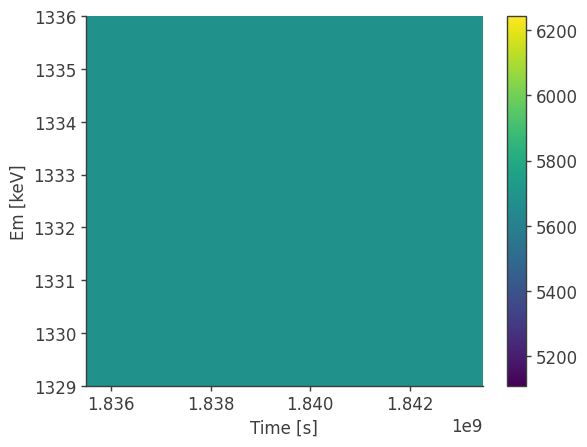

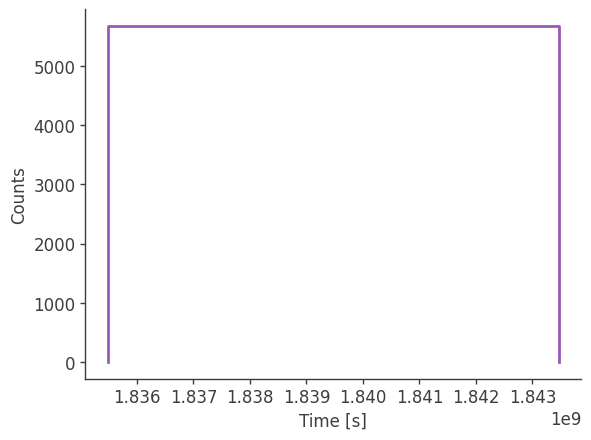

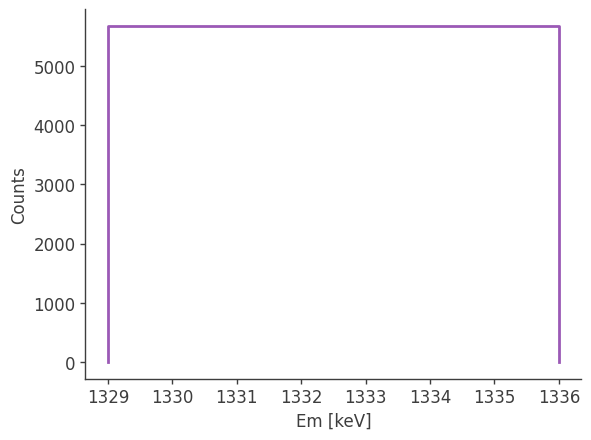

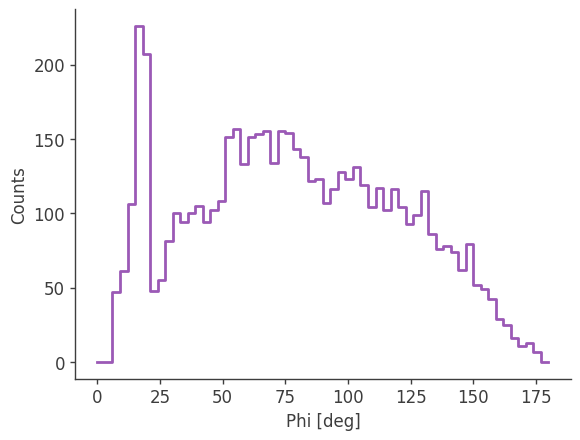

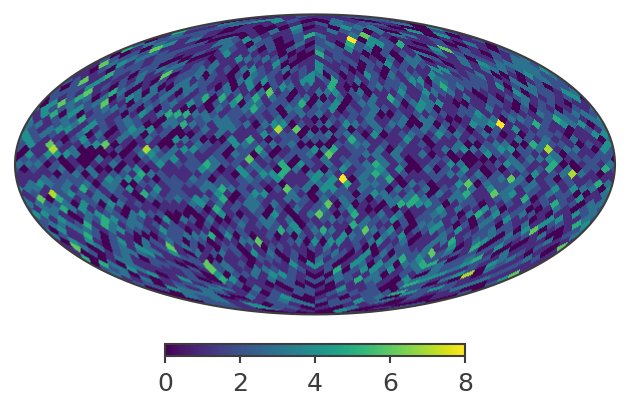

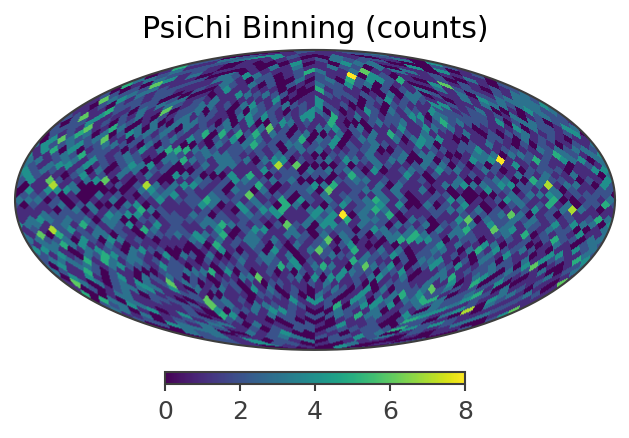

In [50]:
%matplotlib inline

plot = 1
#  --------------------------------------------------------------
# 1. Use the BinnedData to load, get unbinned and binned data, and create psichi plots
#  --------------------------------------------------------------
# create BinnedData object with YAML file

source = BinnedData("inputs.yaml")
# this one is used when
source.get_binned_data(unbinned_data = data_path + Fe60_Source_file, psichi_binning="galactic", make_binning_plots=plot, show_plots=plot)

# time_axis = source.binned_data.axes[0]
# time_axis_edges = time_axis.edges
# print(f"Source time binning:")
# print(f"  Number of bins: {len(time_axis_edges)-1}")
# print(f"  Range: {time_axis_edges[0]:.1f} - {time_axis_edges[-1]:.1f}")
# print(f"  Time edges: {time_axis_edges}") 

# energy_axis = source.binned_data.axes[0]
# energy_axis_edges = energy_axis.edges
# print(f"Source energy binning:")==z
# print(f"  Number of bins: {len(energy_axis_edges)-1}")
# print(f"  Range: {energy_axis_edges[0]:.1f} - {energy_axis_edges[-1]:.1f}")
# print(f"  Energy edges: {energy_axis_edges}") 


# phi_bins = source.binned_data.axes[2]
# phi_axis_edges = phi_bins.edges
# print(f"Source phi binning:")
# print(f"  Number of bins: {len(phi_axis_edges)-1}")
# print(f"  Range: {phi_axis_edges[0]:.1f} - {phi_axis_edges[-1]:.1f}")
# print(f"  phi edges: {phi_axis_edges}") 

# print("[")
# for i in range(60):
#     print(f"{i*3:.1f}," , end="")
# print("}")

In [3]:
#  --------------------------------------------------------------
# 2. Use the BinnedData to load, get unbinned and binned data, and create psichi plots
#  --------------------------------------------------------------
# create BinnedData object with YAML file


binned_bkg = BinnedData("inputs.yaml")
# this one is used when
binned_bkg.load_binned_data_from_hdf5(data_path + Fe60_high_bkg_file)


# print(f"Background time binning:")
# print(f"  Number of bins: {len(background_energy_edges)-1}")
# print(f"  Range: {background_energy_edges[0]:.1f} - {background_energy_edges[-1]:.1f} keV")
# print(f"  time edges: {background_energy_edges}")


# energy_axis = binned_bkg.binned_data.axes[0]
# energy_axis_edges = energy_axis.edges
# print(f"Source energy binning:")
# print(f"  Number of bins: {len(energy_axis_edges)-1}")
# print(f"  Range: {energy_axis_edges[0]} - {energy_axis_edges[-1]}")
# print(f"  Energy edges: {energy_axis_edges}") 

# print(1835487300.0  - 1843467255.0) 

# phi_bins = binned_bkg.binned_data.axes[2]
# phi_axis_edges = phi_bins.edges
# print(f"Source phi binning:")
# print(f"  Number of bins: {len(phi_axis_edges)-1}")
# print(f"  Range: {phi_axis_edges[0]:.1f} - {phi_axis_edges[-1]:.1f}")
# print(f"  phi edges: {phi_axis_edges}") 

if plot:
    binned_bkg.plot_binned_data()

# print(source.__dict__)b

NameError: name 'plot' is not defined

In [6]:
signal = source.binned_data.to_dense()  
bkg = binned_bkg.binned_data.to_dense()

event = signal + bkg

In [ ]:
# signal.write("Fe60_galactic_signal.hdf5", overwrite = True)
# bkg.write("Fe60_galactic_bkg.hdf5", overwrite = True)
# event.write("Fe60_galactic_event.hdf5", overwrite = True)

In [7]:
signal = Histogram.open("Fe60_galactic_signal.hdf5")
bkg = Histogram.open("Fe60_galactic_bkg.hdf5")
event = Histogram.open("Fe60_galactic_event.hdf5")

$\large{\text{Data Reduction}}$

In [8]:
%%time

ori_filepath = data_path + ori_file
ori = SpacecraftFile.parse_from_file(ori_filepath)

CPU times: user 1.72 s, sys: 472 ms, total: 2.19 s
Wall time: 2.19 s


In [9]:
response_path = data_path + response_file_Fe60_high.replace(".zip", "")
image_response = FullDetectorResponse.open(response_path)

nside_local = image_response.nside
npix_local = hp.nside2npix(nside_local)

nside_local, npix_local

(16, 3072)

In [17]:
image_response

NameError: name 'image_response' is not defined

In [10]:
%%time

nside_scatt = nside_local

exposure_table = SpacecraftAttitudeExposureTable.from_orientation(ori, nside = nside_scatt, start = None, stop = None)
exposure_table

  0%|          | 0/531997 [00:00<?, ?it/s]

CPU times: user 12.1 s, sys: 941 ms, total: 13 s
Wall time: 12.9 s


,scatt_binning_index,healpix_index,zpointing,xpointing,zpointing_averaged,xpointing_averaged,delta_time,exposure,num_pointings,bkg_group
0,0,"(2340, 182)","[[22.574117544763574, -31.110730874676822], [2...","[[22.574117544763574, 58.88926912532318], [22....","[22.53186598336207, -31.00790853492029]","[22.534830601784506, 58.99233544039963]","[15.000000000002345, 15.000000000002345, 15.00...",18630.0,1242,0
1,1,"(2340, 222)","[[22.890562060304546, -31.881626976766405], [2...","[[22.890562060304546, 58.1183730232336], [23.2...","[23.25825698290161, -32.7823975777024]","[23.263880268626753, 57.2180802358068]","[14.999999999992752, 15.000000000002345, 15.00...",26010.0,1734,0
2,2,"(2340, 267)","[[23.840879977830582, -34.19868307024379], [23...","[[23.84087997783058, 55.80131692975622], [23.7...","[23.77880720067148, -34.04202634110881]","[23.77903257452164, 55.95800335215191]","[15.000000000002345, 15.000000000002345, 14.99...",5655.0,377,0
3,3,"(2404, 267)","[[24.158420899721513, -34.97241501346041], [24...","[[24.158420899721506, 55.027584986539594], [24...","[24.449149312358237, -35.6831019120271]","[24.459250728663985, 54.3178648092337]","[14.999999999992752, 15.000000000002345, 15.00...",35490.0,2366,0
4,4,"(2404, 315)","[[25.11519953479184, -37.297431342520845], [25...","[[25.115199534791838, 52.70256865747916], [25....","[25.301677686085025, -37.75081792048012]","[25.30377989506407, 52.2493856987317]","[15.000000000002345, 14.999999999992752, 15.00...",16230.0,1082,0
...,...,...,...,...,...,...,...,...,...,...
3091,3091,"(113, 899)","[[18.856258361961434, 64.17240568347188]]","[[198.8562583619614, 25.82759431652813]]","[18.85625836196143, 64.17240568347188]","[198.85625836196138, 25.827594316528135]",[15.000000000002345],15.0,1,0
3092,3092,"(484, 395)","[[24.366312246878625, 42.187500311034995]]","[[204.36631224687858, 47.812499688965005]]","[24.36631224687862, 42.187500311035]","[204.36631224687858, 47.812499688965005]",[15.000000000002345],15.0,1,0
3093,3093,"(548, 395)","[[23.19419869123921, 40.821622250446495]]","[[203.1941986912392, 49.17837774955349]]","[23.194198691239215, 40.821622250446495]","[203.19419869123917, 49.1783777495535]",[15.000000000002345],15.0,1,0
3094,3094,"(675, 201)","[[15.800124514097567, 31.086159136641342]]","[[195.80012451409755, 58.913840863358665]]","[15.800124514097567, 31.086159136641342]","[195.80012451409755, 58.91384086335866]",[15.000000000002345],15.0,1,0


In [ ]:
# exposure_table.save_as_fits("exposure_table_Fe60.fits", overwrite = True)

In [ ]:
# map_pointing_zx = exposure_table.calc_pointing_trajectory_map()
# map_pointing_zx = map_pointing_zx.to_dense()

In [ ]:
# hp.mollview(map_pointing_zx.project('z').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
# hp.graticule(color='gray', dpar = 30)
# plt.show()

# hp.mollview(map_pointing_zx.project('z').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
# hp.graticule(color='gray', dpar = 30)
# plt.show()

In [ ]:
# hp.mollview(map_pointing_zx.project('x').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the X-axis pointing")
# hp.graticule(color='gray', dpar = 30)
# plt.show()

# hp.mollview(map_pointing_zx.project('x').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the X-axis pointing")
# hp.graticule(color='gray', dpar = 30)
# plt.show()

In [ ]:
# %%time

# this is the data reduction step (creates the coordsys conversion matrix)

# nside_model = nside_local

# coordsys_conv_matrix = CoordsysConversionMatrix.spacecraft_attitude_binning_ccm(image_response, exposure_table, nside_model = nside_model, use_averaged_pointing = True)

In [ ]:
# coordsys_conv_matrix.write("ccm_Fe60.hdf5", overwrite = True)

$\large{\text{After data reduction we will make the event data and bkg binned data into local (space craft frame)}}$

In [5]:
# required function 
DEBUG = 0

def get_binned_data_scatt(unbinned_event, exposure_table, psichi_binning = 'local', sparse = False):
    if DEBUG:
        print("The keys of the dataset:", unbinned_event.cosi_dataset.keys())
        print("The keys of the values:", unbinned_event.cosi_dataset)
    exposure_dict = {row['healpix_index']: row['scatt_binning_index'] for _, row in exposure_table.iterrows()}
        
    # from BinnedData.py
 
    # Get energy bins:
    energy_bin_edges = np.array(unbinned_event.energy_bins)
    
    # Get phi bins:
    number_phi_bins = int(180./unbinned_event.phi_pix_size)
    phi_bin_edges = np.linspace(0,180,number_phi_bins+1)
    
    # Define psichi axis and data for binning:
    if psichi_binning == 'galactic':
        psichi_axis = HealpixAxis(nside = unbinned_event.nside, scheme = unbinned_event.scheme, coordsys = 'galactic', label='PsiChi')
        coords = SkyCoord(l=unbinned_event.cosi_dataset['Chi galactic']*u.deg, b=unbinned_event.cosi_dataset['Psi galactic']*u.deg, frame = 'galactic')
    if psichi_binning == 'local':
        psichi_axis = HealpixAxis(nside = unbinned_event.nside, scheme = unbinned_event.scheme, coordsys = SpacecraftFrame(), label='PsiChi')
        coords = SkyCoord(lon=unbinned_event.cosi_dataset['Chi local']*u.rad, lat=((np.pi/2.0) - unbinned_event.cosi_dataset['Psi local'])*u.rad, frame = SpacecraftFrame())

    # Define scatt axis and data for binning
    n_scatt_bins = len(exposure_table)
    scatt_axis = Axis(np.arange(n_scatt_bins + 1), label='ScAtt')
    
    is_nest = True if exposure_table.scheme == 'nested' else False
    
    nside_scatt = exposure_table.nside
    
    zindex = hp.ang2pix(nside_scatt, unbinned_event.cosi_dataset['Zpointings (glon,glat)'].T[0] * 180 / np.pi, 
                        unbinned_event.cosi_dataset['Zpointings (glon,glat)'].T[1] * 180 / np.pi, nest=is_nest, lonlat=True)
    xindex = hp.ang2pix(nside_scatt, unbinned_event.cosi_dataset['Xpointings (glon,glat)'].T[0] * 180 / np.pi, 
                        unbinned_event.cosi_dataset['Xpointings (glon,glat)'].T[1] * 180 / np.pi, nest=is_nest, lonlat=True)    
    scatt_data = np.array( [ exposure_dict[(z, x)] + 0.5 if (z,x) in exposure_dict.keys() else -1 for z, x in zip(zindex, xindex)] ) # should this "0.5" be needed?
    
    # Initialize histogram:
    binned_data = Histogram([scatt_axis,
                              Axis(energy_bin_edges*u.keV, label='Em'),
                              Axis(phi_bin_edges*u.deg, label='Phi'),
                              psichi_axis],
                              sparse=sparse)

    # Fill histogram:
    binned_data.fill(scatt_data, unbinned_event.cosi_dataset['Energies']*u.keV, np.rad2deg(unbinned_event.cosi_dataset['Phi'])*u.deg, coords)    
    
    return binned_data

In [ ]:
ccm = CoordsysConversionMatrix.open(data_path + "ccm_Fe60.hdf5")

exposure_table = SpacecraftAttitudeExposureTable.from_fits(data_path+"exposure_table_Fe60.fits")

ori = SpacecraftFile.parse_from_file(data_path + ori_file)

In [6]:
# load the source (signal)

signal_filepath = data_path + "511_thin_disk_3months_unbinned_data.fits.gz"

unbinned_signal = UnBinnedData(input_yaml = "inputs.yaml")

unbinned_signal.cosi_dataset = unbinned_signal.get_dict_from_fits(data_path + Fe60_Source_file)

binned_signal_scatt = get_binned_data_scatt(unbinned_signal, exposure_table, psichi_binning = 'local', sparse = False)


In [ ]:
import h5py

In [ ]:

def get_dict_from_hdf5(object, input_hdf5):

    this_dict = {}
    # Fill dictionary from input h5fy file:
    hf = h5py.File(input_hdf5,"r")
    keys = list(hf.keys())
    for each in keys:
        this_dict[each] = np.array(hf[each])

    return this_dict

In [ ]:
unbinned_bkg = UnBinnedData(input_yaml = "inputs.yaml")
unbinned_bkg.cosi_dataset = get_dict_from_hdf5(data_path + Fe60_high_bkg_file)
# binned_bkg_scatt = get_binned_data_scatt(unbinned_bkg, exposure_table, psichi_binning = 'local', sparse = False)

TypeError: Accessing a group is done with bytes or str, not <class 'slice'>

In [ ]:
%%time

bkg_filepath = data_path + albedo_bkg_file

unbinned_bkg = UnBinnedData(input_yaml = "inputs.yaml")

unbinned_bkg.cosi_dataset = unbinned_bkg.get_dict_from_fits(bkg_filepath)

binned_bkg_scatt = get_binned_data_scatt(unbinned_bkg, exposure_table, psichi_binning = 'local', sparse = False)

CPU times: user 51.5 s, sys: 9.02 s, total: 1min
Wall time: 1min


In [ ]:
binned_event_scatt = binned_signal_scatt + binned_bkg_scatt

In [ ]:
binned_signal_scatt.write(data_path + "60Fe_scatt_signal.hdf5", overwrite=True)
binned_bkg_scatt.write(data_path + "60Fe_scatt_bkg.hdf5", overwrite=True)
binned_event_scatt.write(data_path + "60Fe_scatt_event.hdf5", overwrite=True)

In [ ]:
#load all the data again
ccm = CoordsysConversionMatrix.open(data_path + "ccm_Fe60.hdf5")
exposure_table = SpacecraftAttitudeExposureTable.from_fits(data_path+"exposure_table_Fe60.fits")
ori = SpacecraftFile.parse_from_file(data_path + ori_file)

response_path = data_path + response_file_Fe60_high.replace(".zip", "")
response = FullDetectorResponse.open(response_path)

binned_event = BinnedData("inputs.yaml")
binned_event.load_binned_data_from_hdf5(data_path + "60Fe_scatt_event.hdf5")

binned_bkg_scatt = BinnedData("inputs.yaml")
binned_bkg_scatt.load_binned_data_from_hdf5(data_path + "60Fe_scatt_bkg.hdf5")

In [14]:
%%time

di = DataIF_COSI_DC2.load(name = "Fe60",
                        event_binned_data = binned_event.binned_data,
                        dict_bkg_binned_data = {"albedo": binned_bkg_scatt.binned_data},
                        rsp = response,
                        coordsys_conv_matrix=ccm)

CPU times: user 8.58 s, sys: 1min 4s, total: 1min 13s
Wall time: 2min 39s


In [15]:
parameter_filepath = "imagedeconvolution_Fe60.yml"

In [16]:
image_deconvolution = ImageDeconvolution()

# set data_interface to image_deconvolution
image_deconvolution.set_dataset([di])

# set a parameter file for the image deconvolution
image_deconvolution.read_parameterfile(parameter_filepath)

In [ ]:
# image_deconvolution.override_parameter("deconvolution:parameter:iteration_max = 30")
# image_deconvolution.override_parameter("deconvolution:parameter:background_normalization_optimization:activate = True")
# image_deconvolution.override_parameter("deconvolution:parameter:acceleration:alpha_max = 10")
# image_deconvolution.override_parameter("deconvolution:parameter:smoothing:FWHM:value = 3.0")


In [17]:
image_deconvolution.initialize()

In [ ]:
%%time

image_deconvolution.run_deconvolution()

  0%|          | 0/10 [00:00<?, ?it/s]


WARNING RuntimeWarning: invalid value encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



In [ ]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-likelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

In [ ]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['alpha'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("alpha")
plt.show()

In [ ]:
x, y = [], []

for result in image_deconvolution.results:
    x.append(result['iteration'])
    y.append(result['log-likelihood'])
    
plt.plot(x, y)
plt.grid()
plt.xlabel("iteration")
plt.ylabel("log-likelihood")
plt.show()

In [ ]:
def plot_reconstructed_image(result, source_position = None): # source_position should be (l,b) in degrees
    iteration = result['iteration']
    image = result['model']

    for energy_index in range(image.axes['Ei'].nbins):
        map_healpxmap = HealpixMap(data = image[:,energy_index], unit = image.unit)

        _, ax = map_healpxmap.plot('mollview')        
        
        _.colorbar.set_label(str(image.unit))
        
        if source_position is not None:
            ax.scatter(source_position[0]*u.deg, source_position[1]*u.deg, transform=ax.get_transform('world'), color = 'red')

        plt.title(label = f"iteration = {iteration}, energy_index = {energy_index} ({image.axes['Ei'].bounds[energy_index][0]}-{image.axes['Ei'].bounds[energy_index][1]})")

In [ ]:
iteration = 9

plot_reconstructed_image(image_deconvolution.results[iteration])

In [ ]:
iteration_idx = 9

result = image_deconvolution.results[iteration_idx]

iteration = result['iteration']
image = result['model']

data = image[:,0]
data[data <= 0 * data.unit] = 1e-12 * data.unit

hp.mollview(data, min = 2e-5, norm ='log', unit = str(data.unit), title = f'511 keV image at {iteration}th iteration', cmap = 'magma')

plt.show()